In [1]:
import numpy as np
import scanpy as sc
import scvelo as scv
import scanorama
import numpy as np


sc.set_figure_params(dpi=120, frameon=False)
scv.settings.verbosity = 3
scv.settings.presenter_view = True


In [2]:
from pathlib import Path

paths = sorted(Path("/mnt/d/scgeo/data/GSE280305_h5ad").glob("GSM*_count.h5ad"))
ads = [sc.read_h5ad(p) for p in paths]
[(p.name, a.shape, a.obs["timepoint"].unique().tolist()) for p, a in zip(paths, ads)]


[('GSM8594491_D8_count.h5ad', (13149, 32285), ['D8']),
 ('GSM8594492_D11_count.h5ad', (4513, 32285), ['D11']),
 ('GSM8594493_D14_count.h5ad', (5614, 32285), ['D14']),
 ('GSM8594494_D21_count.h5ad', (8329, 32285), ['D21'])]

In [3]:
for ad in ads: 
    ad.var_names_make_unique()

In [4]:
common = set(ads[0].var_names)
for a in ads[1:]:
    common &= set(a.var_names)
common = sorted(common)

ads = [a[:, common].copy() for a in ads]
for a in ads:
    a.var = a.var.loc[common]

adata = sc.concat(
    ads,
    label="timepoint",
    keys=[a.obs["timepoint"].unique()[0] for a in ads],
    join="inner",
    merge="same",
)
adata


AnnData object with n_obs × n_vars = 31605 × 32285
    obs: 'timepoint', 'sample', 'gsm'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [5]:
del ads

In [6]:
# Basic QC vars (optional)
adata.var["mt"] = adata.var_names.str.startswith("mt-") | adata.var_names.str.startswith("Mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Standard normalization for embeddings (NOT for velocity)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [7]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key="timepoint",
    flavor="seurat_v3"
)
adata = adata[:, adata.var["highly_variable"]].copy()
adata


AnnData object with n_obs × n_vars = 31605 × 3000
    obs: 'timepoint', 'sample', 'gsm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [8]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")


In [9]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, key_added="nbrs_raw")
sc.tl.umap(adata, neighbors_key="nbrs_raw")
adata.obsm["X_umap_raw"] = adata.obsm["X_umap"].copy()


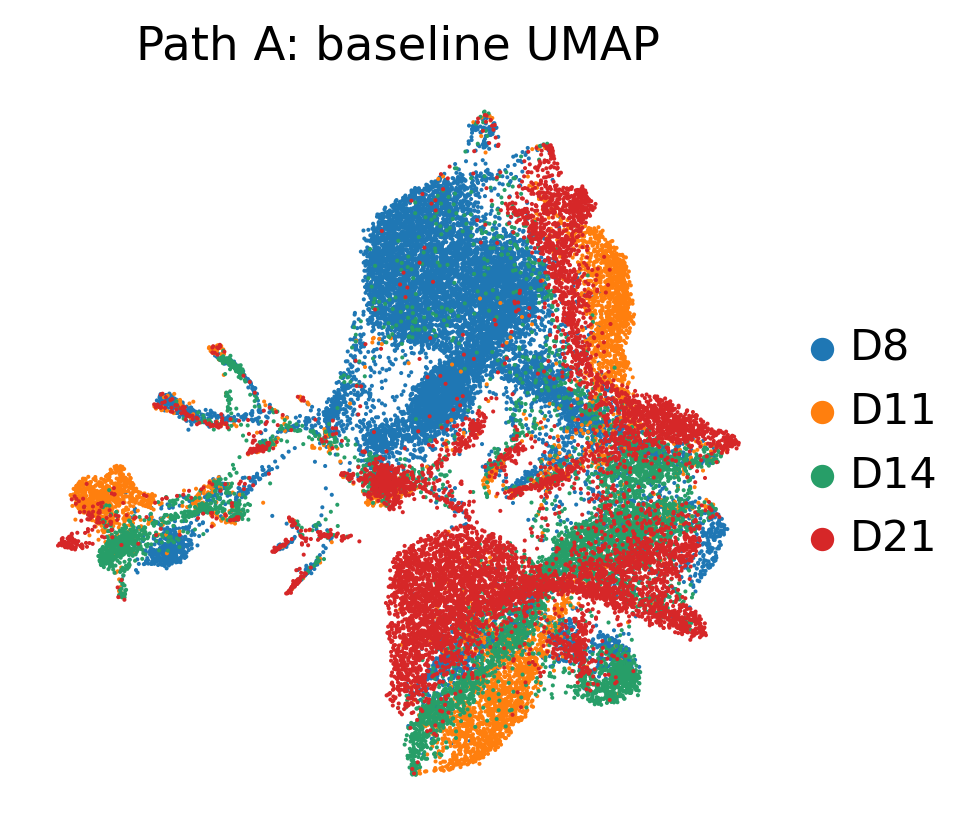

In [10]:
sc.pl.umap(adata, color="timepoint", title="Path A: baseline UMAP", size=6)


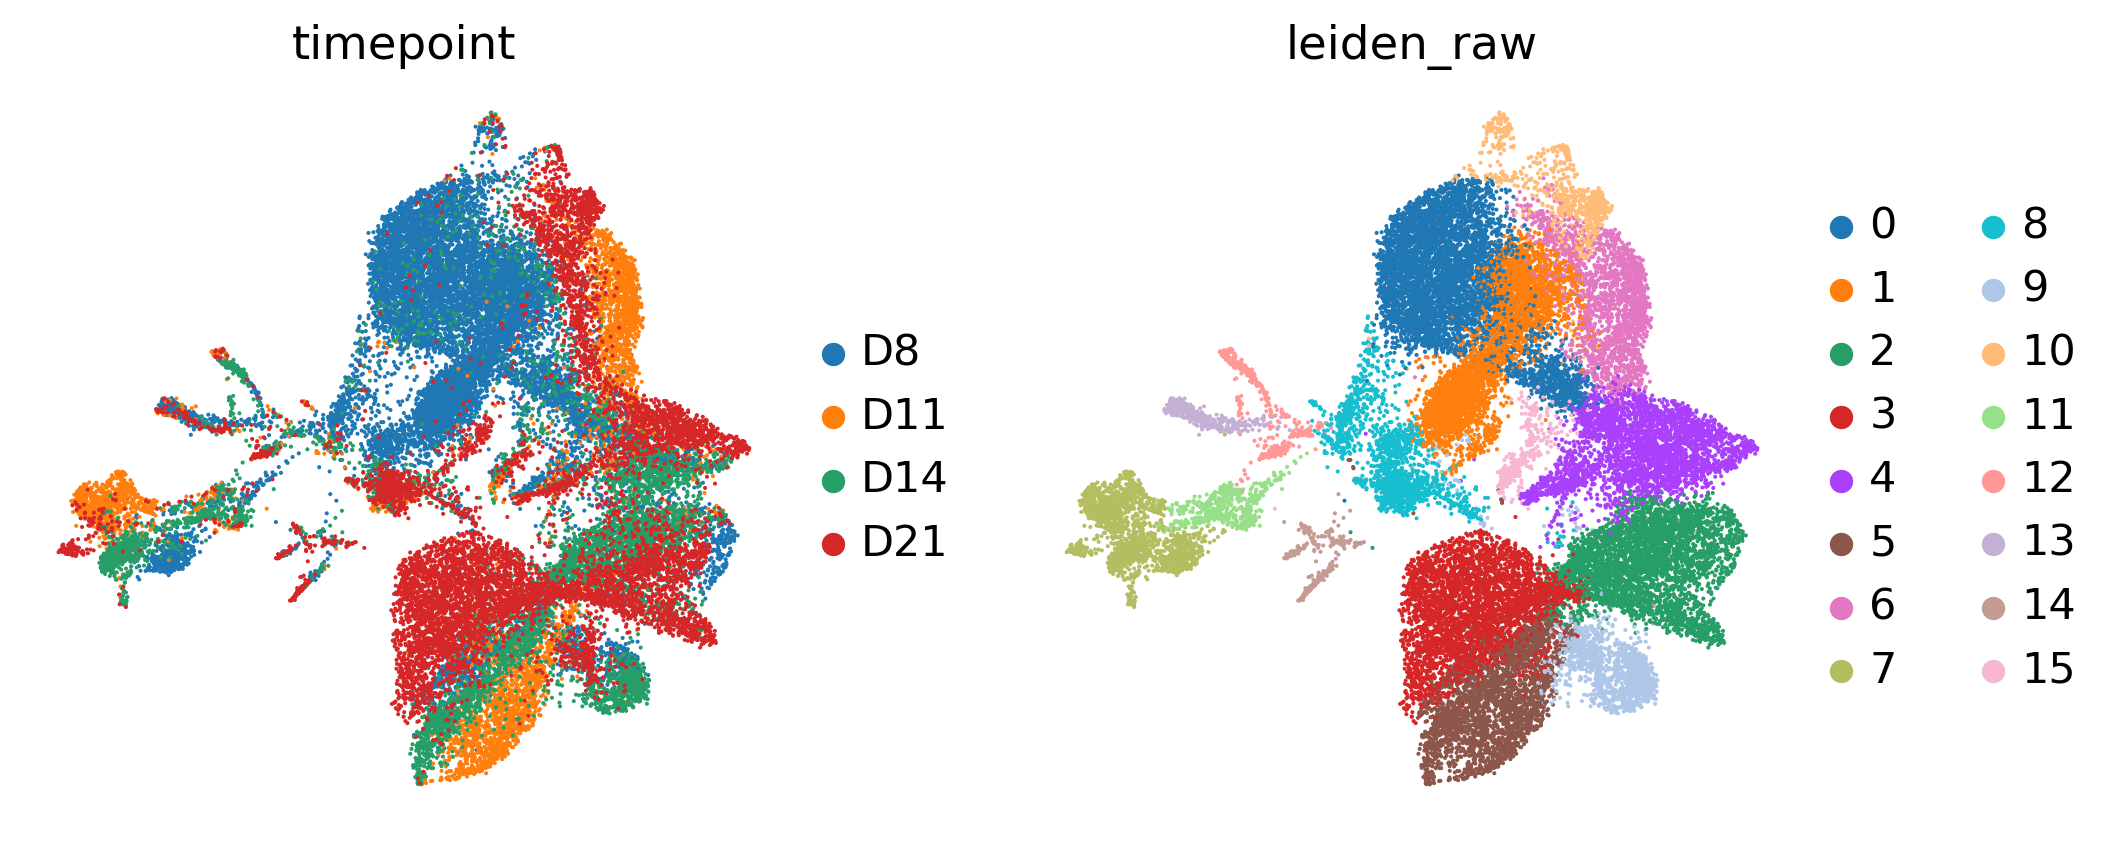

In [11]:
sc.tl.leiden(adata, resolution=0.5, neighbors_key="nbrs_raw", key_added="leiden_raw")
sc.pl.umap(adata, color=["timepoint", "leiden_raw"], size=6)


In [12]:
import time


out = Path("data/GSE280305_paths_checkpoint.h5ad")
t0 = time.time()
adata.write(out)
print(f"Saved checkpoint -> {out}  ({time.time()-t0:.1f}s)")


Saved checkpoint -> data/GSE280305_paths_checkpoint.h5ad  (9.1s)


In [13]:
out_light = Path("data/GSE280305_paths_light.h5ad")
adata_light = adata.copy()
# drop heavy layers if present (usually they are not in this HVG/log object)
for k in list(adata_light.layers.keys()):
    del adata_light.layers[k]
adata_light.write(out_light)
print(f"Saved light -> {out_light}")
del adata_light


Saved light -> data/GSE280305_paths_light.h5ad


Found 3000 genes among all datasets
Processing datasets (2, 3)
Processing datasets (0, 2)
Processing datasets (1, 3)
Processing datasets (0, 1)
Processing datasets (0, 3)
Processing datasets (1, 2)


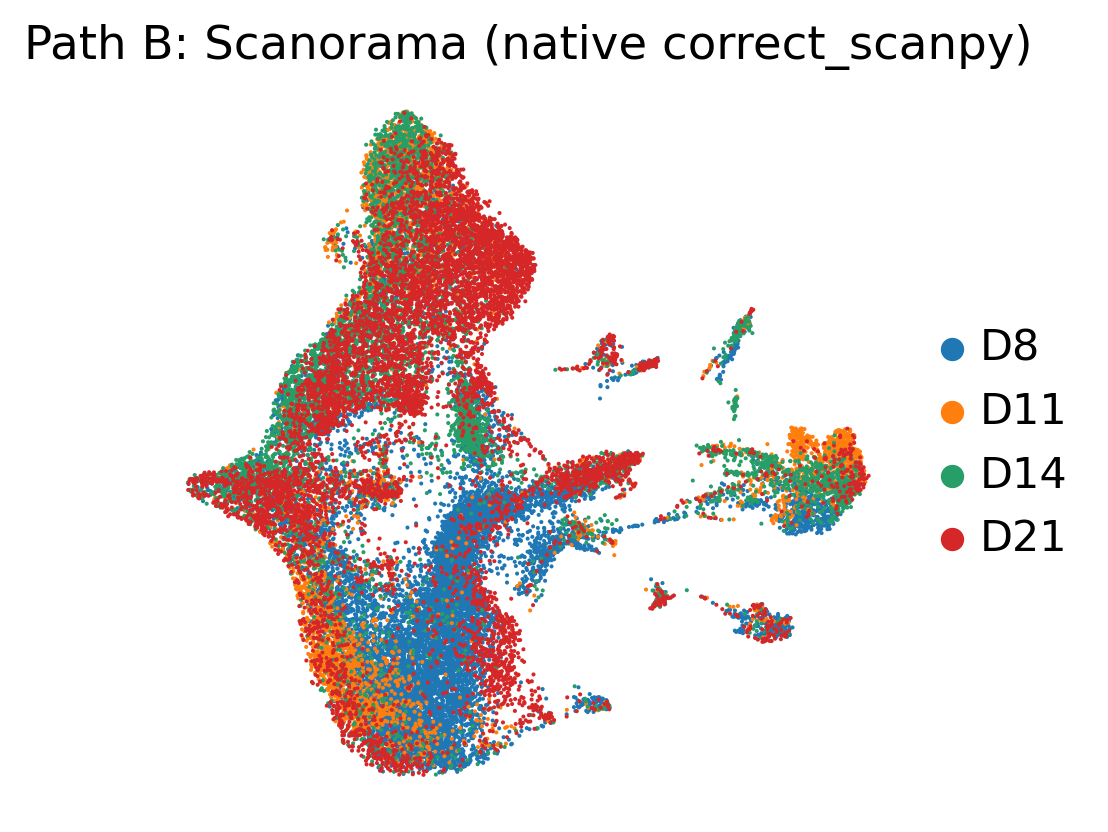

In [14]:


# --- 1) Split into per-timepoint AnnData objects (keeps obs_names intact) ---
tps = ["D8", "D11", "D14", "D21"]
adatas = [adata[adata.obs["timepoint"] == tp].copy() for tp in tps]

# Ensure unique gene names inside each object (safety)
for a in adatas:
    a.var_names_make_unique()

# Optional: restrict to HVGs already in adata (recommended)
# If you already subset adata to HVGs earlier, this is already true.
# Otherwise, do it here:
# hvgs = adata.var_names[adata.var["highly_variable"]].tolist()
# adatas = [a[:, hvgs].copy() for a in adatas]

# --- 2) Run Scanorama native correction with low-dim embedding output ---
# return_dimred=True adds X_scanorama to each AnnData in `adatas`
corrected = scanorama.correct_scanpy(
    adatas,
    return_dimred=True,
    dimred=50,            # match your PCA comps; adjust if needed
    verbose=1
)

# --- 3) Reattach integrated embedding back into the master adata, preserving row order ---
# Build a single matrix in the same order as adata.obs_names
X_scan = np.zeros((adata.n_obs, corrected[0].obsm["X_scanorama"].shape[1]), dtype=np.float32)

# Create index map from cell name -> row index in master
idx = {cell: i for i, cell in enumerate(adata.obs_names)}

for tp, a_corr in zip(tps, corrected):
    # Sanity: ensure we have the embedding
    assert "X_scanorama" in a_corr.obsm, f"Missing X_scanorama for {tp}"
    # Fill rows for these cells
    rows = [idx[c] for c in a_corr.obs_names]
    X_scan[rows, :] = a_corr.obsm["X_scanorama"].astype(np.float32)

adata.obsm["X_scanorama"] = X_scan

# Clean up
del adatas, corrected, X_scan

# --- 4) Build neighbors/UMAP using Scanorama space ---
sc.pp.neighbors(adata, use_rep="X_scanorama", key_added="nbrs_scanorama")
sc.tl.umap(adata, neighbors_key="nbrs_scanorama")
adata.obsm["X_umap_scanorama"] = adata.obsm["X_umap"].copy()

sc.pl.embedding(adata, "X_umap_scanorama", color="timepoint", title="Path B: Scanorama (native correct_scanpy)", size=6)


In [15]:
from sklearn.neighbors import NearestNeighbors

def timepoint_mixing(adata, rep, k=30, key="timepoint"):
    X = adata.obsm[rep]
    labs = adata.obs[key].to_numpy()
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)
    idx = nn.kneighbors(X, return_distance=False)[:, 1:]  # drop self
    # fraction of neighbors with a different label
    return np.mean(labs[idx] != labs[:, None])

print("Raw UMAP mixing:", timepoint_mixing(adata, "X_umap_raw"))
print("Scanorama UMAP mixing:", timepoint_mixing(adata, "X_umap_scanorama"))


Raw UMAP mixing: 0.2788050413964035
Scanorama UMAP mixing: 0.4470052206929283


In [16]:
# Make sure you have these stored
assert "X_umap_raw" in adata.obsm, "Missing X_umap_raw (Path A)."
assert "nbrs_raw" in adata.uns, "Missing nbrs_raw neighbors (Path A)."

# Optional: store PCA explicitly too
if "X_pca_raw" not in adata.obsm and "X_pca" in adata.obsm:
    adata.obsm["X_pca_raw"] = adata.obsm["X_pca"].copy()

print("Path A locked:", adata.obsm["X_umap_raw"].shape)


Path A locked: (31605, 2)


In [17]:
assert "X_scanorama" in adata.obsm, "Missing X_scanorama (native Scanorama embedding)."
assert "nbrs_scanorama" in adata.uns, "Missing nbrs_scanorama neighbors."
assert "X_umap_scanorama" in adata.obsm, "Missing X_umap_scanorama."

print("Path B locked:", adata.obsm["X_scanorama"].shape, adata.obsm["X_umap_scanorama"].shape)


Path B locked: (31605, 50) (31605, 2)


In [18]:
out = Path("data/GSE280305_paths_AB.h5ad")
adata.write(out)
print(f"Saved AB -> {out}")


Saved AB -> data/GSE280305_paths_AB.h5ad
